Bölüm 100	Ortalama Skor: 9.51
Bölüm 200	Ortalama Skor: 9.20
Bölüm 300	Ortalama Skor: 9.40
Bölüm 400	Ortalama Skor: 9.47
Bölüm 500	Ortalama Skor: 9.43
Bölüm 600	Ortalama Skor: 9.58
Bölüm 700	Ortalama Skor: 9.40
Bölüm 800	Ortalama Skor: 9.38
Bölüm 900	Ortalama Skor: 9.32
Bölüm 1000	Ortalama Skor: 9.39
Bölüm 1100	Ortalama Skor: 9.52
Bölüm 1200	Ortalama Skor: 9.42
Bölüm 1300	Ortalama Skor: 9.35
Bölüm 1400	Ortalama Skor: 9.55
Bölüm 1500	Ortalama Skor: 9.31
Bölüm 1600	Ortalama Skor: 9.40
Bölüm 1700	Ortalama Skor: 9.55
Bölüm 1800	Ortalama Skor: 9.54
Bölüm 1900	Ortalama Skor: 9.38
Bölüm 2000	Ortalama Skor: 9.45
Bölüm 2100	Ortalama Skor: 9.33
Bölüm 2200	Ortalama Skor: 9.58
Bölüm 2300	Ortalama Skor: 9.44
Bölüm 2400	Ortalama Skor: 9.30
Bölüm 2500	Ortalama Skor: 9.50
Bölüm 2600	Ortalama Skor: 9.56
Bölüm 2700	Ortalama Skor: 9.52
Bölüm 2800	Ortalama Skor: 9.45
Bölüm 2900	Ortalama Skor: 9.41
Bölüm 3000	Ortalama Skor: 9.45
Bölüm 3100	Ortalama Skor: 9.46
Bölüm 3200	Ortalama Skor: 9.46
Bölüm 3300	Ortala

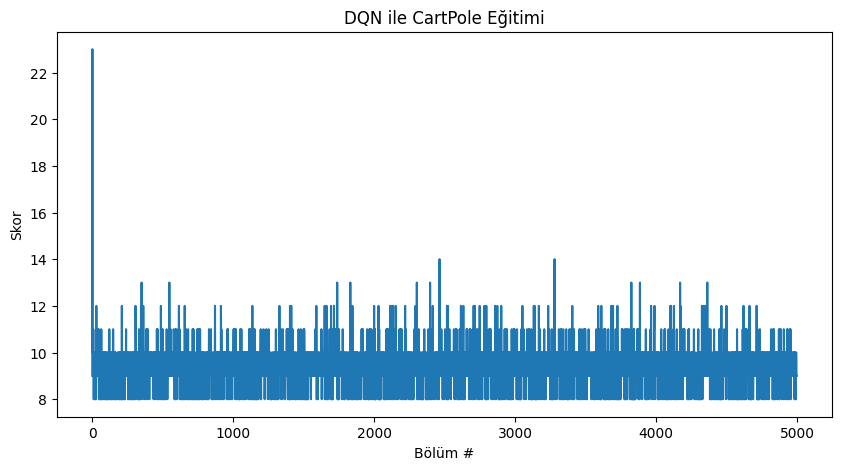

In [3]:
import gymnasium as gym
import torch
import numpy as np
import random
import os
import sys
from collections import deque
import matplotlib.pyplot as plt

# --- Proje Kök Dizinini Python Path'e Ekleme ---
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

# --- Kendi Ajan Modülümüzü İçe Aktarma ---
from src.agents.simple_dqn import DQNAgent

# --- Kurulum ve Seed Ayarları ---
def set_seed(seed_value=42):
    torch.manual_seed(seed_value)
    np.random.seed(seed_value)
    random.seed(seed_value)
    # env.action_space.seed(seed_value) # Gymnasium'un yeni sürümlerinde bu gerekmeyebilir

set_seed(42)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# --- Ortamı Oluşturma ---
env = gym.make("CartPole-v1")
obs_space_size = env.observation_space.shape[0]
action_space_size = env.action_space.n

# --- Ajanı Oluşturma ---
agent = DQNAgent(obs_space_size, action_space_size, device)

# --- Eğitim Parametreleri ---
total_episodes = 5000
max_steps = 1000
epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.5

scores_deque = deque(maxlen=100)
scores = []

# --- Ana Eğitim Döngüsü ---
for episode in range(1, total_episodes + 1):
    state, _ = env.reset()
    score = 0
    for t in range(max_steps):
        # 1. Eylem seç
        action = agent.select_action(state, epsilon)
        
        # 2. Etkileşimde bulun
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        
        # 3. Deneyimi sakla ve öğren
        agent.step(state, action, reward, next_state, done)
        
        state = next_state
        score += reward
        if done:
            break
            
    scores_deque.append(score)
    scores.append(score)
    
    # Epsilon'u azalt
    epsilon = max(epsilon_min, epsilon_decay * epsilon)
    
    if episode % 100 == 0:
        print(f'\rBölüm {episode}\tOrtalama Skor: {np.mean(scores_deque):.2f}')

# --- Sonuçları Görselleştirme ---
plt.figure(figsize=(10, 5))
plt.plot(np.arange(len(scores)), scores)
plt.ylabel('Skor')
plt.xlabel('Bölüm #')
plt.title('DQN ile CartPole Eğitimi')
plt.show()

env.close()
